# RNA virtual screening workflow

This notebook presents a simplified computational workflow inspired by RNA-targeted virtual screening and chemical space analysis. The workflow includes docking score analysis, dimensionality reduction, scaffold exploration and qualitative interpretation of computational results.

## Scientific background

RNA-targeted drug discovery represents a growing area in computational chemistry and structure-based drug design. Due to the structural flexibility of RNA systems, conformational diversity may significantly influence virtual screening outcomes and hit identification.
This notebook explores simplified workflows commonly applied in cheminformatics and computational analysis of RNA-ligand interactions.

In [4]:
#import
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

import umap.umap_ as umap

## Simulated dataset

A simplified dataset was generated to reproduce typical outputs obtained in virtual screening workflows.
The dataset includes:
- ligand identifiers
- docking scores
- conformational state (APO/HOLO)
- database origin
- molecular descriptors

In [5]:
np.random.seed(42)

n = 120

states = np.random.choice(["Ligand_Free", "Ligand_Bound"], n)
databases = np.random.choice(["Database_A", "Database_B"], n)

scores = np.random.normal(-7.5, 1.2, n)

mw = np.random.normal(420, 60, n)
logp = np.random.normal(3.1, 0.8, n)
tpsa = np.random.normal(95, 20, n)

smiles_list = [
    "CCO",
    "CCN",
    "CCCN",
    "CCOC",
    "CC(C)O"
] * 24

df = pd.DataFrame({
    "Ligand": [f"Lig_{i}" for i in range(n)],
    "State": states,
    "Database": databases,
    "DockingScore": scores,
    "MolWt": mw,
    "LogP": logp,
    "TPSA": tpsa,
    "SMILES": smiles_list
})

df.head()

,Ligand,State,Database,DockingScore,MolWt,LogP,TPSA,SMILES
0,Lig_0,Ligand_Free,Database_B,-8.342464,477.240106,3.160644,75.285479,CCO
1,Lig_1,Ligand_Bound,Database_A,-7.893195,459.083475,2.558271,105.080930,CCN
2,Lig_2,Ligand_Free,Database_B,-7.970530,401.083845,3.880096,84.394848,CCCN
3,Lig_3,Ligand_Free,Database_A,-9.256218,465.538153,2.982354,79.142543,CCOC
4,Lig_4,Ligand_Free,Database_A,-7.144656,373.630487,2.439602,92.859393,CC(C)O


## Docking score cutoff
Docking score thresholds are commonly used to identify potentially interesting compounds during virtual screening campaigns.
In this simplified workflow, compounds with docking scores lower than -8 are considered top-ranked candidates.

In [6]:
#dockingscore cutoff
top_df = df[df["DockingScore"] < -8]

print(f"Top compounds: {len(top_df)}")

Top compounds: 38


## Docking Score Distribution
The distribution of docking scores provides an overview of screening behavior across the simulated dataset.

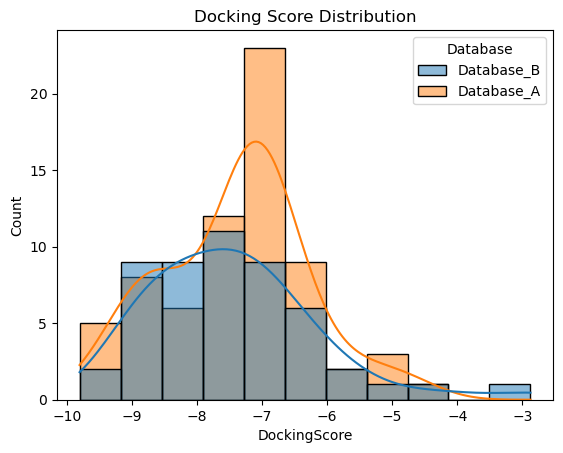

In [7]:
#distribuzione
sns.histplot(
    data=df,
    x="DockingScore",
    hue="Database",
    kde=True
)

plt.title("Docking Score Distribution")
plt.show()

## Interpretation

Differences in docking score distributions may suggest distinct chemical space composition between databases. However, docking scores alone should not be interpreted as definitive indicators of binding affinity and require structural and chemical context.

# Dimensionality reduction
## PCA Analysis
Principal Component Analysis (PCA) was applied to explore chemical space organization according to molecular descriptors.

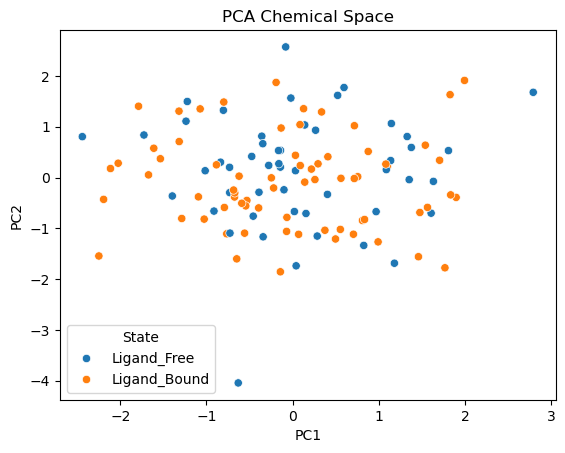

In [8]:
#pca
features = df[["MolWt", "LogP", "TPSA"]]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
pcs = pca.fit_transform(scaled)

pca_df = pd.DataFrame(pcs, columns=["PC1", "PC2"])
pca_df["State"] = df["State"]

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="State"
)

plt.title("PCA Chemical Space")
plt.show()

## PCA Interpretation

PCA enables dimensionality reduction while preserving relevant variance within molecular descriptor datasets.
The resulting chemical space representation may help identify clustering behavior and physicochemical trends associated with different conformational states.

## UMAP Visualization

UMAP was used as a non-linear dimensionality reduction technique to explore local organization of chemical space.

/Users/rebeccasessa/miniforge3/envs/bblean/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


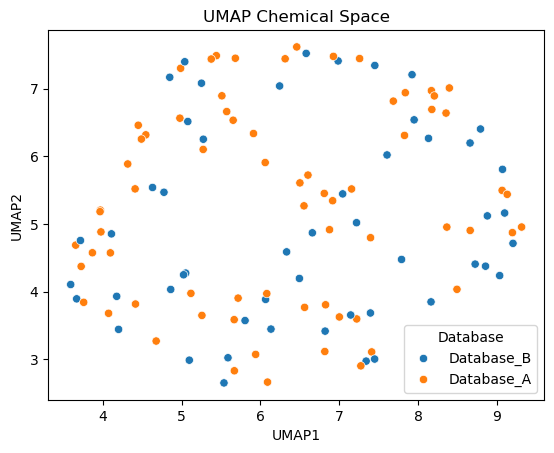

In [9]:
#umap
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(scaled)

umap_df = pd.DataFrame(embedding, columns=["UMAP1", "UMAP2"])
umap_df["Database"] = df["Database"]

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Database"
)

plt.title("UMAP Chemical Space")
plt.show()

## t-SNE Visualization

t-SNE was applied to investigate local neighborhood organization and potential subgroup separation within the dataset.

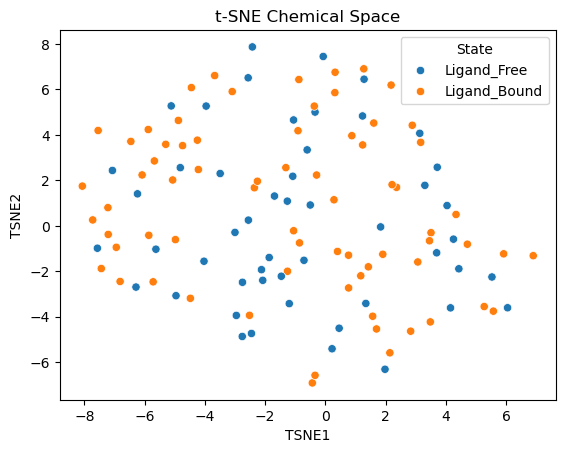

In [10]:
#tsne
tsne = TSNE(n_components=2, random_state=42)

tsne_embedding = tsne.fit_transform(scaled)


tsne_df = pd.DataFrame(tsne_embedding, columns=["TSNE1", "TSNE2"])
tsne_df["State"] = df["State"]

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="State"
)

plt.title("t-SNE Chemical Space")
plt.show()

# Ligand-free vs Ligand-bound comparison

Conformational diversity may influence virtual screening enrichment and the identification of distinct chemotypes.
This simplified analysis compares simulated APO and HOLO screening outputs.

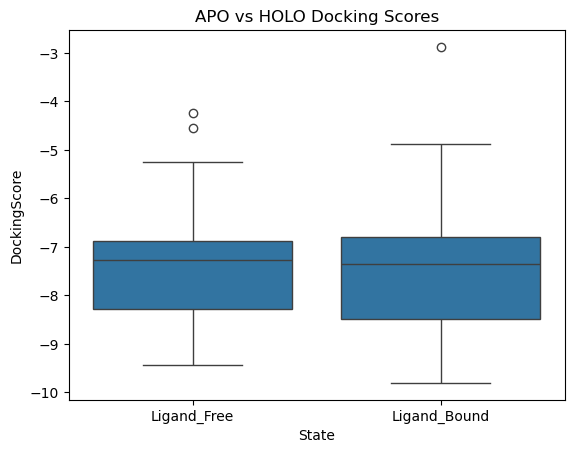

In [11]:
#apovsholo
sns.boxplot(
    data=df,
    x="State",
    y="DockingScore"
)

plt.title("APO vs HOLO Docking Scores")
plt.show()

## Interpretation

Differences between Ligand-Free and Ligand-Bound conformational states may influence docking enrichment behavior and chemical diversity.

Including multiple conformational states may reduce structure-dependent bias during virtual screening workflows.

# Scaffold Analysis
## Murcko Scaffold Analysis

Murcko scaffolds provide simplified structural representations useful for evaluating chemotype diversity.

In [12]:
#murko
scaffolds = []

for smi in df["SMILES"]:
    mol = Chem.MolFromSmiles(smi)

    if mol:
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    else:
        scaffold = None

    scaffolds.append(scaffold)


df["Scaffold"] = scaffolds


df["Scaffold"].value_counts()

Scaffold
    120
Name: count, dtype: int64

# Clustering
## Clustering Perspective

Chemical clustering approaches can help identify structurally related compounds and evaluate diversity enrichment during screening campaigns.

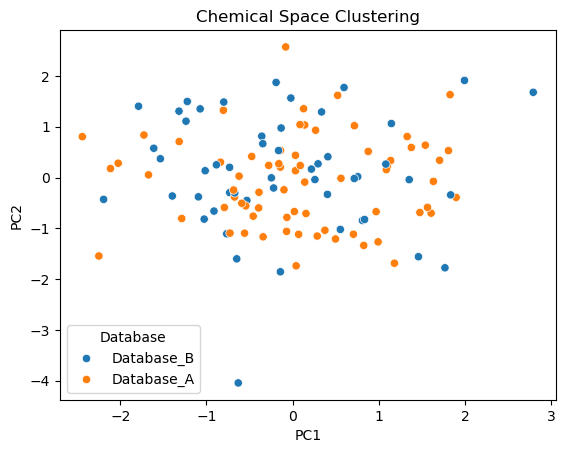

In [13]:
#clustering
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=df["Database"]
)

plt.title("Chemical Space Clustering")
plt.show()

# Limitations
The analyses presented in this notebook are educational and based on simulated datasets.

Real virtual screening campaigns require significantly larger datasets, structural validation and experimental integration.

# Conclusions
This notebook presents a simplified computational workflow inspired by RNA-targeted virtual screening.
The analyses combine docking score interpretation, chemical space exploration and dimensionality reduction approaches commonly used in computational chemistry and cheminformatics.
Scientific interpretation remains essential for contextualizing computational outputs and supporting structure-based drug discovery workflows.